In [21]:
import pandas as pd

In [22]:
train=pd.read_csv('german_credit_data.csv')
train.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [23]:
train.shape

(1000, 11)

In [24]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [25]:
train["Sex"].unique()

array(['male', 'female'], dtype=object)

In [26]:
train["Job"].unique()

array([2, 1, 3, 0])

In [27]:
train["Housing"].unique()

array(['own', 'free', 'rent'], dtype=object)

In [28]:
train["Saving accounts"].unique()

array([nan, 'little', 'quite rich', 'rich', 'moderate'], dtype=object)

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le_housing = LabelEncoder()
le_job = LabelEncoder()
le_sex = LabelEncoder()
le_saving = LabelEncoder()
le_checking = LabelEncoder()
le_Purpose = LabelEncoder()
le_risk = LabelEncoder()

train["Housing"] = le_housing.fit_transform(train["Housing"])
train["Job"] = le_job.fit_transform(train["Job"])
train["Sex"] = le_sex.fit_transform(train["Sex"])
train["Saving accounts"] = le_saving.fit_transform(train["Saving accounts"])
train["Checking account"] = le_checking.fit_transform(train["Checking account"])
train["Purpose"] = le_Purpose.fit_transform(train["Purpose"])
train["Risk"] = le_risk.fit_transform(train["Risk"])

In [30]:
train.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,1,2,1,4,0,1169,6,5,1
1,1,22,0,2,1,0,1,5951,48,5,0
2,2,49,1,1,1,0,3,2096,12,3,1
3,3,45,1,2,0,0,0,7882,42,4,1
4,4,53,1,2,0,0,0,4870,24,1,0


In [31]:
train.drop('Unnamed: 0',axis=1,inplace=True)

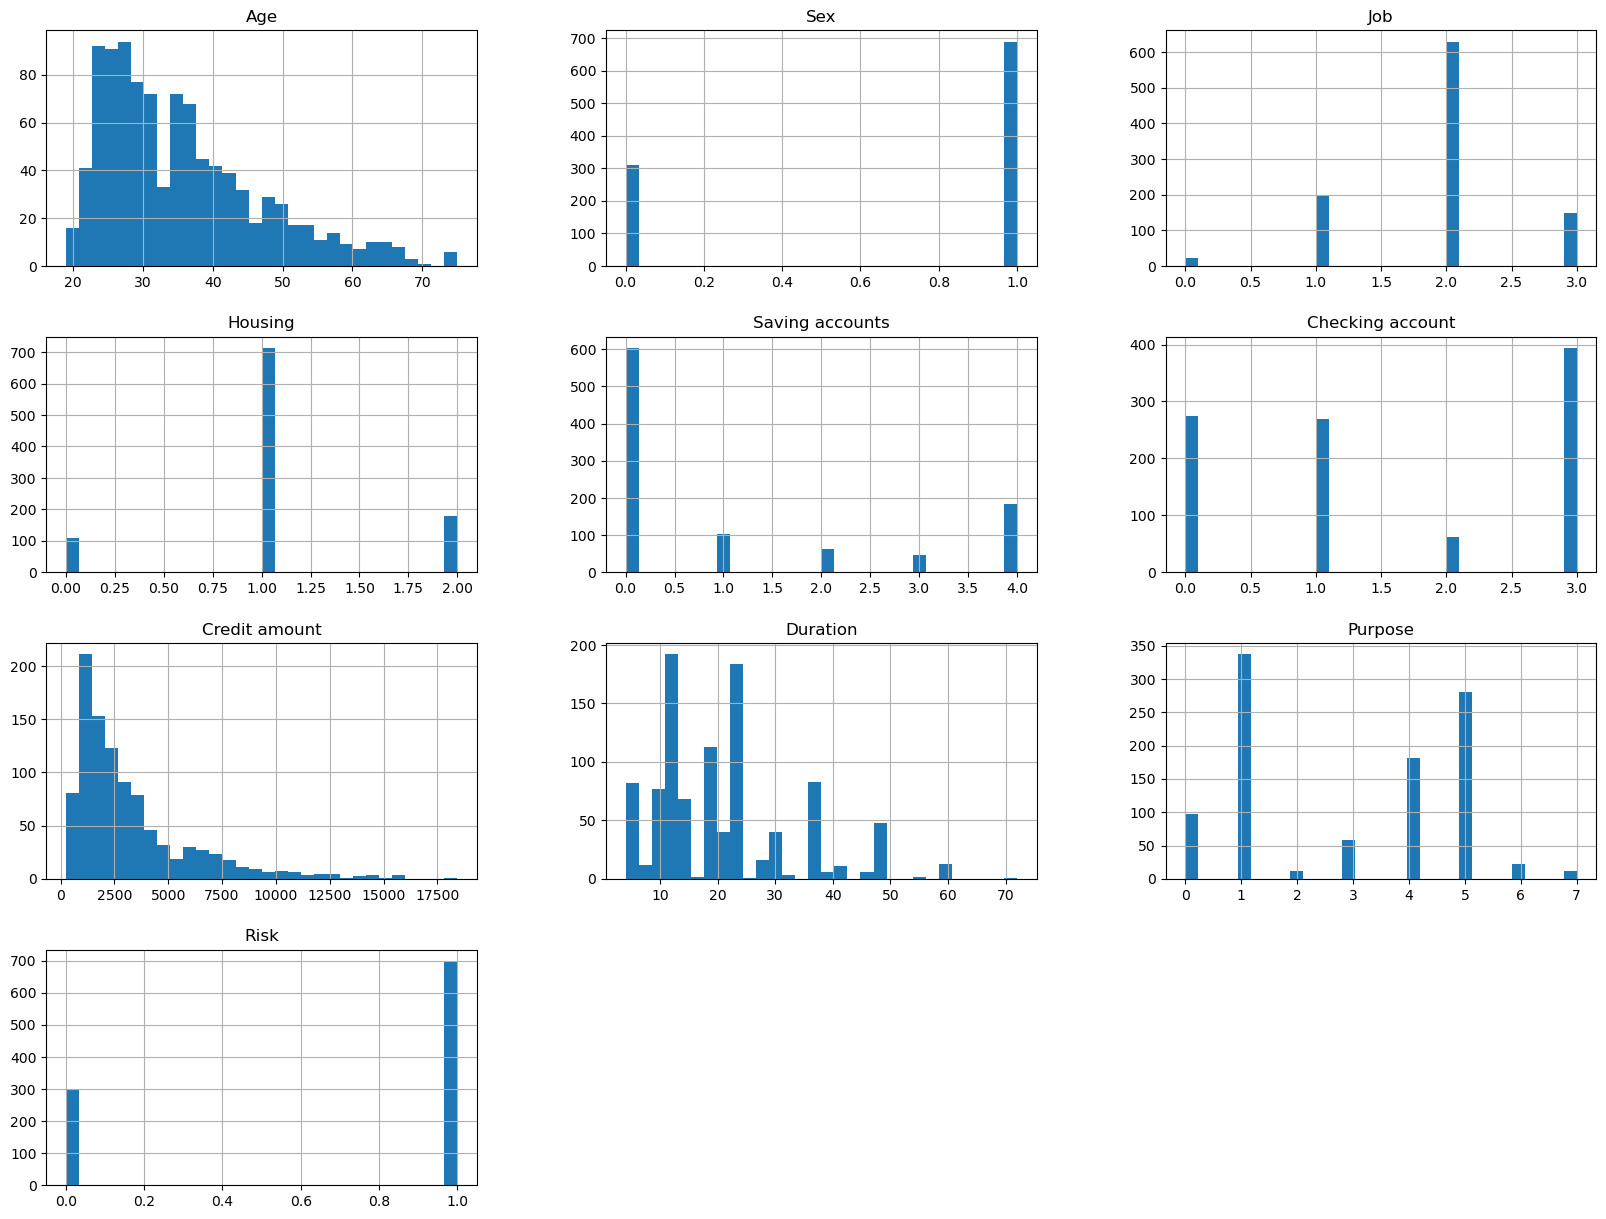

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
train.hist(bins=30, figsize=(20,15))
plt.show()


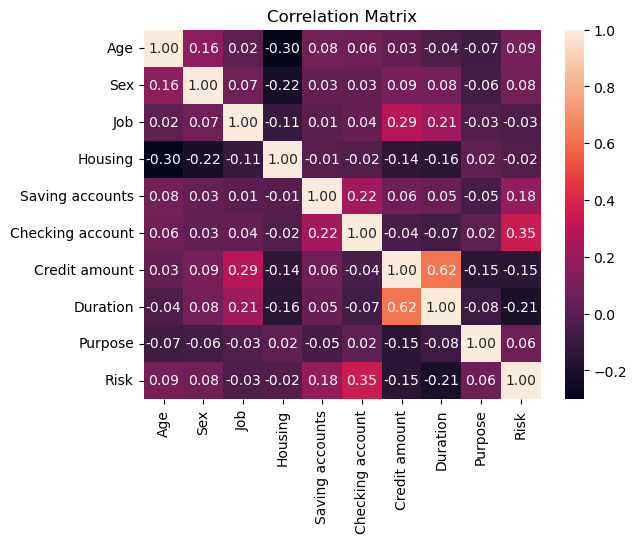

In [57]:
sns.heatmap(train.corr(),annot=True,fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [34]:
features=train.drop('Risk',axis=1)
target=train['Risk']

In [35]:
df_model=train[features.columns.tolist()+['Risk']]


In [36]:
features.fillna(features.mean(),inplace=True)
features.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

In [37]:
X=df_model.drop('Risk',axis=1)
y=df_model['Risk']

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error,accuracy_score
import warnings
warnings.filterwarnings('ignore')
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy*100:.2f}%')
print(f'Mean Squared Error: {mean_squared_error(y_test,y_pred):.4f}')

Accuracy: 76.00%
Mean Squared Error: 0.2400


In [59]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
accuracy_rf=accuracy_score(y_test,y_pred_rf)
print(f'Random Forest Accuracy: {accuracy_rf*100:.2f}%')

Random Forest Accuracy: 77.00%


In [60]:
from sklearn.svm import SVC
svm_model=SVC(kernel='rbf',random_state=42)
svm_model.fit(X_train,y_train)
y_pred_svm=svm_model.predict(X_test)
accuracy_svm=accuracy_score(y_test,y_pred_svm)
print(f'SVM Accuracy: {accuracy_svm*100:.2f}%')


SVM Accuracy: 71.50%


In [61]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,random_state=42)
gb_model.fit(X_train,y_train)
y_pred_gb=gb_model.predict(X_test)
accuracy_gb=accuracy_score(y_test,y_pred_gb)

print(f'Gradient Boosting Accuracy: {accuracy_gb*100:.2f}%')

Gradient Boosting Accuracy: 76.50%


In [62]:
best_model=rf_model
rf_model.fit(X,y)

RandomForestClassifier(random_state=42)

In [63]:
y_pred=rf_model.predict(X)
accuracy_final=accuracy_score(y,y_pred)

In [64]:
print(f'Final Model Accuracy on entire dataset: {accuracy_final*100:.2f}%')

Final Model Accuracy on entire dataset: 100.00%


In [65]:
import joblib

joblib.dump({
    "housing": le_housing,
    "job": le_job,
    "sex": le_sex,
    "saving": le_saving,
    "checking": le_checking,
    "Purpose": le_Purpose,
    "risk": le_risk
}, "encoders.pkl")

joblib.dump(best_model, "credit_model.pkl")

print("Model and encoders saved successfully!")

Model and encoders saved successfully!
